# 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

**Domain:** E-Commerce and Retail Analytics  
**Techniques:** RFM Analysis · KMeans Clustering · Collaborative Filtering · Cosine Similarity  

---

## Step 1: Dataset Collection and Understanding

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import warnings, pickle, os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('Set2')

print('All libraries loaded ✅')

All libraries loaded ✅


In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
df = pd.read_excel('ecommerce_data.xlsx', dtype={'CustomerID': str})
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print('Shape:', df.shape)
df.head()

Shape: (200292, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV536365,21915,PRODUCT 098,19,2023-07-24 18:45:00,6.79,12853,United Kingdom
1,INV536365,66155,PRODUCT 090,15,2023-07-24 18:45:00,7.43,12853,United Kingdom
2,INV536365,88504,PRODUCT 146,8,2023-07-24 18:45:00,1.18,12853,United Kingdom
3,INV536365,17685,PRODUCT 262,19,2023-07-24 18:45:00,14.86,12853,United Kingdom
4,INV536365,85674,PRODUCT 028,10,2023-07-24 18:45:00,8.03,12853,United Kingdom


In [3]:
# ── Basic info ────────────────────────────────────────────────────────────────
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200292 entries, 0 to 200291
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    200292 non-null  str           
 1   StockCode    200292 non-null  int64         
 2   Description  200292 non-null  str           
 3   Quantity     200292 non-null  int64         
 4   InvoiceDate  200292 non-null  datetime64[us]
 5   UnitPrice    200292 non-null  float64       
 6   CustomerID   196287 non-null  str           
 7   Country      200292 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 19.7 MB


In [4]:
# ── Summary statistics ────────────────────────────────────────────────────────
df.describe()

,StockCode,Quantity,InvoiceDate,UnitPrice
count,200292.000000,200292.000000,200292,200292.000000
mean,54068.807581,9.699624,2022-12-31 06:06:40.067402,7.271161
min,10074.000000,-9.000000,2022-01-01 08:08:00,0.650000
25%,31174.000000,5.000000,2022-07-01 11:07:00,3.390000
50%,53309.000000,10.000000,2022-12-31 18:49:00,6.790000
75%,77839.000000,15.000000,2023-07-01 14:03:30,11.020000
max,99733.000000,19.000000,2024-01-01 18:50:00,14.860000
std,26289.503355,5.832896,NaN,4.294366


In [5]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': pct})[missing > 0]

,Missing Count,Missing %
CustomerID,4005,2.0


In [6]:
# ── Duplicate check ───────────────────────────────────────────────────────────
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Unique Customers: {df["CustomerID"].nunique()}')
print(f'Unique Products : {df["Description"].nunique()}')
print(f'Unique Invoices : {df["InvoiceNo"].nunique()}')
print(f'Date Range      : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')

Duplicate rows: 0
Unique Customers: 4000
Unique Products : 300


Unique Invoices : 50000
Date Range      : 2022-01-01 → 2024-01-01


## Step 2: Data Preprocessing

In [7]:
raw_count = len(df)

# 1. Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])
print(f'After dropping missing CustomerID: {len(df):,} rows (removed {raw_count - len(df):,})')

# 2. Exclude cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'After removing cancellations   : {len(df):,} rows')

# 3. Remove non-positive quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f'After removing invalid qty/price: {len(df):,} rows')

# 4. Compute TotalPrice per line
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# 5. Clean Description
df['Description'] = df['Description'].str.strip().str.upper()
df['CustomerID'] = df['CustomerID'].astype(str).str.strip()

print(f'\nFinal clean dataset: {df.shape}')
df.head()

After dropping missing CustomerID: 196,287 rows (removed 4,005)


After removing cancellations   : 192,297 rows
After removing invalid qty/price: 192,297 rows

Final clean dataset: (192297, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,INV536365,21915,PRODUCT 098,19,2023-07-24 18:45:00,6.79,12853,United Kingdom,129.01
1,INV536365,66155,PRODUCT 090,15,2023-07-24 18:45:00,7.43,12853,United Kingdom,111.45
2,INV536365,88504,PRODUCT 146,8,2023-07-24 18:45:00,1.18,12853,United Kingdom,9.44
3,INV536365,17685,PRODUCT 262,19,2023-07-24 18:45:00,14.86,12853,United Kingdom,282.34
4,INV536365,85674,PRODUCT 028,10,2023-07-24 18:45:00,8.03,12853,United Kingdom,80.30


## Step 3: Exploratory Data Analysis (EDA)

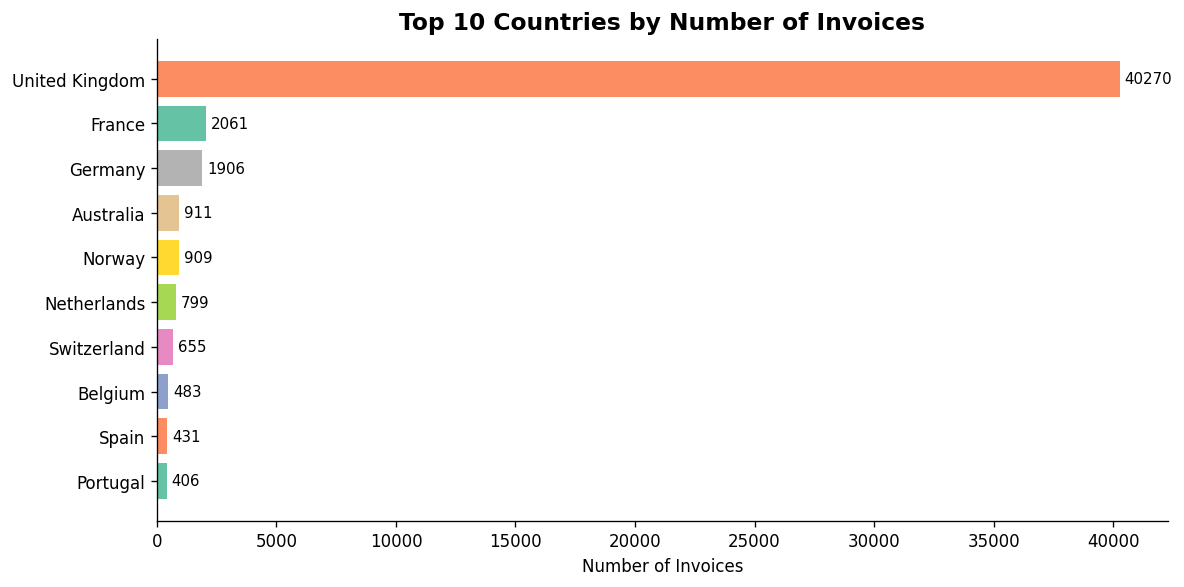

In [8]:
# ── 3.1 Transaction volume by country ─────────────────────────────────────────
country_orders = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(country_orders.index[::-1], country_orders.values[::-1], color=sns.color_palette('Set2', 10))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Top 10 Countries by Number of Invoices', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Invoices')
plt.tight_layout()
plt.savefig('eda_country_orders.png', bbox_inches='tight')
plt.show()

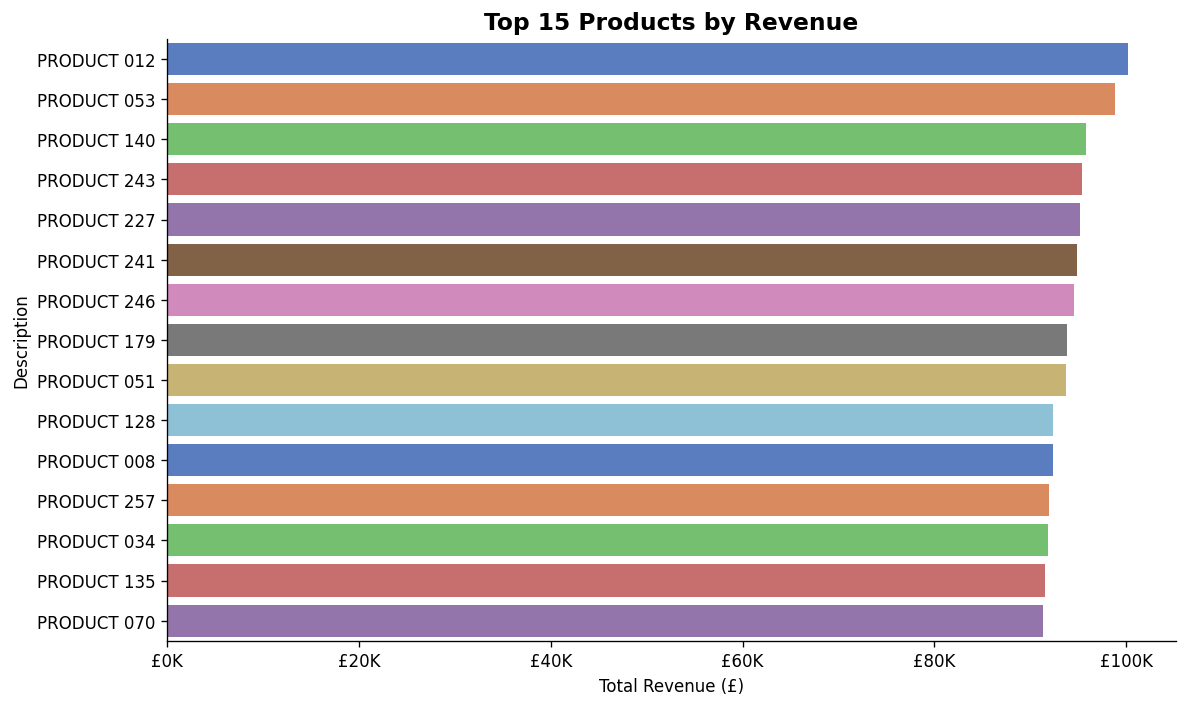

In [9]:
# ── 3.2 Top-selling products by revenue ───────────────────────────────────────
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='muted', ax=ax)
ax.set_title('Top 15 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('eda_top_products.png', bbox_inches='tight')
plt.show()

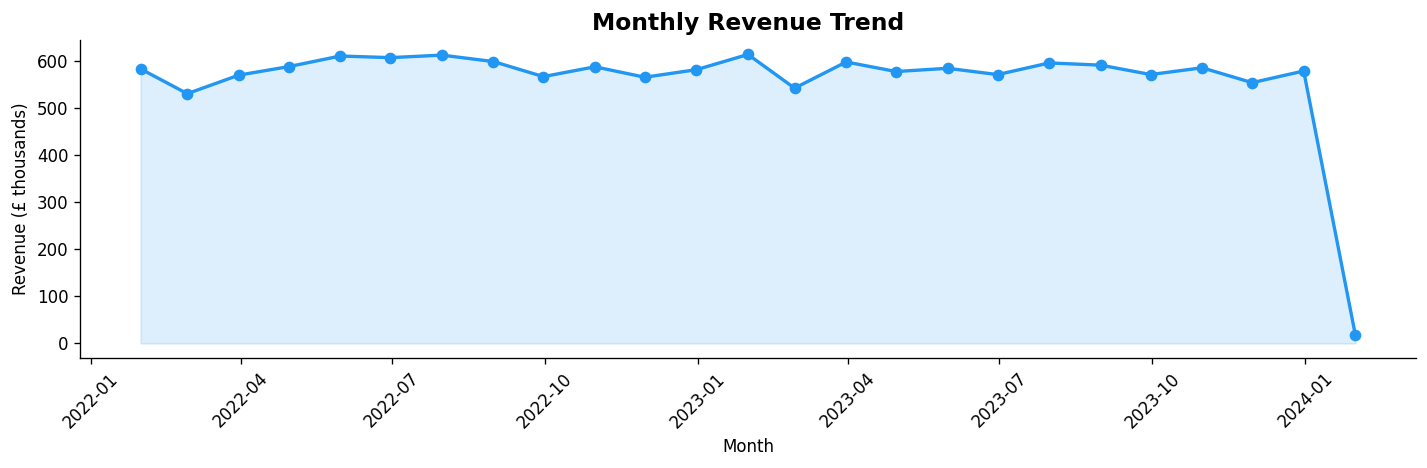

In [10]:
# ── 3.3 Purchase trends over time ─────────────────────────────────────────────
monthly = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum() / 1000

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2, color='#2196F3')
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#2196F3')
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (£ thousands)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_monthly_trend.png', bbox_inches='tight')
plt.show()

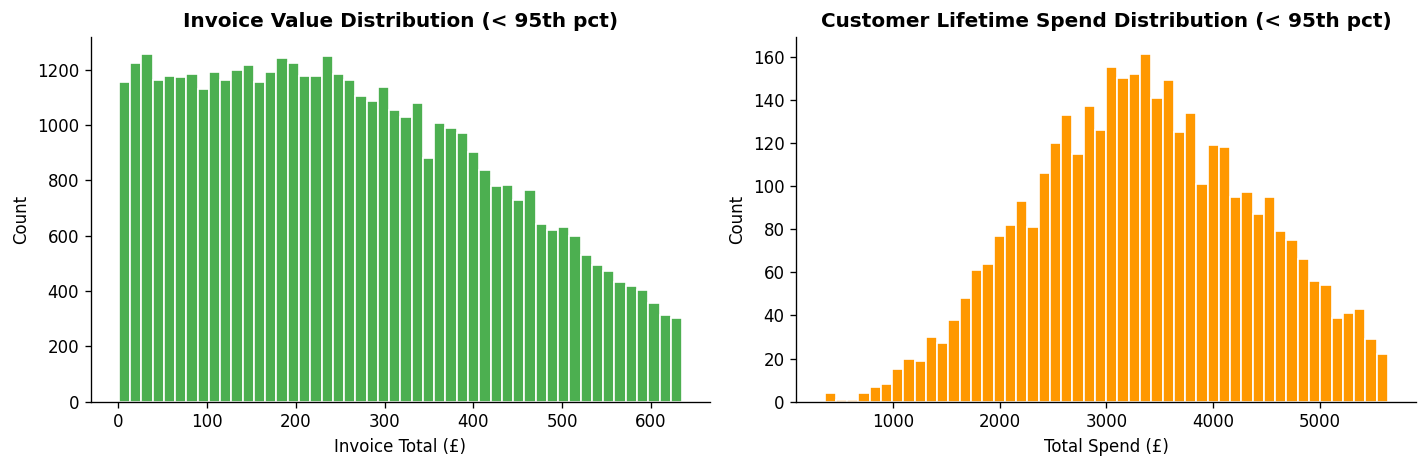

In [11]:
# ── 3.4 Monetary distribution per transaction ─────────────────────────────────
tx_totals = df.groupby('InvoiceNo')['TotalPrice'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tx_totals[tx_totals < tx_totals.quantile(0.95)], bins=50, color='#4CAF50', edgecolor='white')
axes[0].set_title('Invoice Value Distribution (< 95th pct)', fontweight='bold')
axes[0].set_xlabel('Invoice Total (£)')
axes[0].set_ylabel('Count')

cust_totals = df.groupby('CustomerID')['TotalPrice'].sum()
axes[1].hist(cust_totals[cust_totals < cust_totals.quantile(0.95)], bins=50, color='#FF9800', edgecolor='white')
axes[1].set_title('Customer Lifetime Spend Distribution (< 95th pct)', fontweight='bold')
axes[1].set_xlabel('Total Spend (£)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_monetary_dist.png', bbox_inches='tight')
plt.show()

## Step 4: RFM Feature Engineering & Clustering

In [12]:
# ── 4.1 Compute RFM ───────────────────────────────────────────────────────────
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date (reference): {snapshot_date.date()}')

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f'RFM table shape: {rfm.shape}')
rfm.describe().round(2)

Snapshot date (reference): 2024-01-02


RFM table shape: (4000, 4)


,Recency,Frequency,Monetary
count,4000.00,4000.00,4000.00
mean,60.15,12.21,3495.10
std,58.70,3.43,1199.30
min,1.00,3.00,359.55
25%,18.00,10.00,2653.62
50%,42.00,12.00,3397.56
75%,84.00,14.00,4237.53
max,473.00,26.00,9091.10


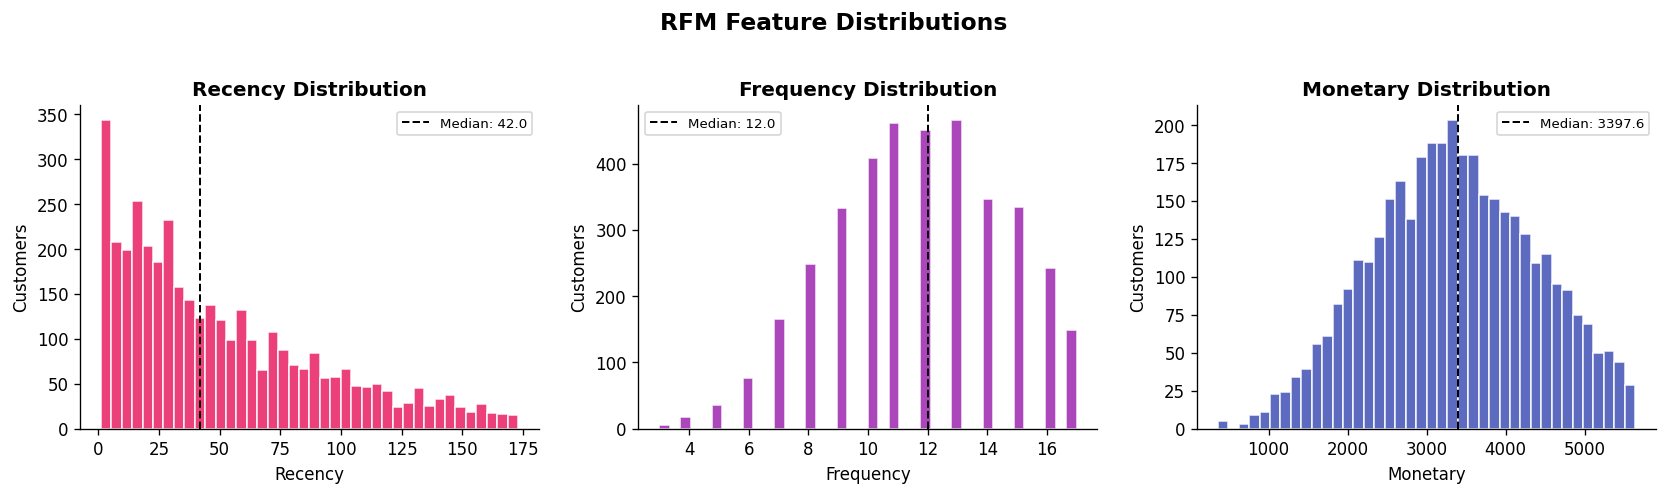

In [13]:
# ── 4.2 RFM Distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#E91E63', '#9C27B0', '#3F51B5']

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], colors):
    data = rfm[col]
    ax.hist(data[data < data.quantile(0.95)], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Customers')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_distributions.png', bbox_inches='tight')
plt.show()

In [14]:
# ── 4.3 Standardize RFM ───────────────────────────────────────────────────────
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
print('Scaled RFM (first 5 rows):')
print(pd.DataFrame(rfm_scaled, columns=['Recency_s', 'Frequency_s', 'Monetary_s']).head())

Scaled RFM (first 5 rows):
   Recency_s  Frequency_s  Monetary_s
0  -0.735268    -0.060596   -0.455625
1  -0.547842    -0.060596   -0.909422
2  -0.462648     0.231083    0.154267
3  -0.820461     1.689479    1.203088
4  -0.598958     1.106121    0.913074


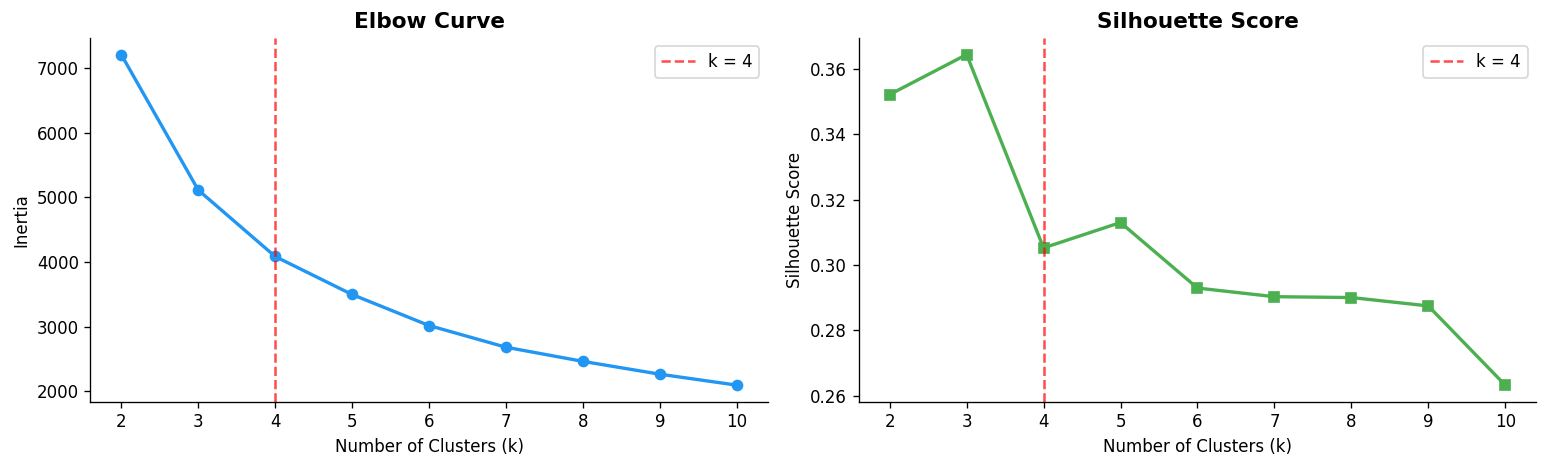

Silhouette scores: {2: 0.352, 3: 0.364, 4: 0.305, 5: 0.313, 6: 0.293, 7: 0.29, 8: 0.29, 9: 0.287, 10: 0.263}


In [15]:
# ── 4.4 Elbow Method & Silhouette Score ──────────────────────────────────────
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, marker='o', color='#2196F3', linewidth=2)
axes[0].set_title('Elbow Curve', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(4, color='red', linestyle='--', alpha=0.7, label='k = 4')
axes[0].legend()

axes[1].plot(K_range, silhouettes, marker='s', color='#4CAF50', linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(4, color='red', linestyle='--', alpha=0.7, label='k = 4')
axes[1].legend()

plt.tight_layout()
plt.savefig('cluster_selection.png', bbox_inches='tight')
plt.show()

print(f'Silhouette scores: {dict(zip(K_range, [round(s,3) for s in silhouettes]))}')

In [16]:
# ── 4.5 Final KMeans with k=4 ────────────────────────────────────────────────
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

sil = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f'Final Silhouette Score (k={OPTIMAL_K}): {sil:.4f}')
print(f'Final Inertia                         : {kmeans.inertia_:.2f}')

Final Silhouette Score (k=4): 0.3052
Final Inertia                         : 4086.61


In [17]:
# ── 4.6 Label clusters from RFM means ───────────────────────────────────────
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print('Cluster RFM Averages:')
print(cluster_summary)

# Assign segment labels based on the RFM averages
# High Value: low recency (recent), high freq, high monetary
# At-Risk   : high recency (old), low freq, low monetary
# Regular   : medium freq, medium monetary
# Occasional: low freq, low monetary but not as old

sorted_by_monetary = cluster_summary['Monetary'].rank(ascending=False)
sorted_by_recency  = cluster_summary['Recency'].rank(ascending=True)   # lower = more recent = better
sorted_by_freq     = cluster_summary['Frequency'].rank(ascending=False)

scores = sorted_by_monetary + sorted_by_recency + sorted_by_freq
label_map = {}
sorted_clusters = scores.sort_values().index.tolist()
segment_labels  = ['High-Value', 'Regular', 'Occasional', 'At-Risk']
for cluster, label in zip(sorted_clusters, segment_labels):
    label_map[cluster] = label

rfm['Segment'] = rfm['Cluster'].map(label_map)
print('\nCluster → Segment mapping:')
for c, l in label_map.items():
    print(f'  Cluster {c} → {l}')

Cluster RFM Averages:
         Recency  Frequency  Monetary
Cluster                              
0           44.7       16.9    5208.5
1           45.3        9.0    2345.5
2           40.9       12.9    3662.3
3          178.3       10.0    2874.2

Cluster → Segment mapping:
  Cluster 0 → High-Value
  Cluster 2 → Regular
  Cluster 3 → Occasional
  Cluster 1 → At-Risk


In [18]:
# ── 4.7 Cluster profile table ────────────────────────────────────────────────
profile = rfm.groupby('Segment').agg(
    Customers = ('CustomerID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean')
).round(1)
profile['% Share'] = (profile['Customers'] / profile['Customers'].sum() * 100).round(1)
profile.sort_values('Avg_Monetary', ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,% Share
Segment,,,,,
High-Value,784,44.7,16.9,5208.5,19.6
Regular,1586,40.9,12.9,3662.3,39.6
Occasional,502,178.3,10.0,2874.2,12.6
At-Risk,1128,45.3,9.0,2345.5,28.2


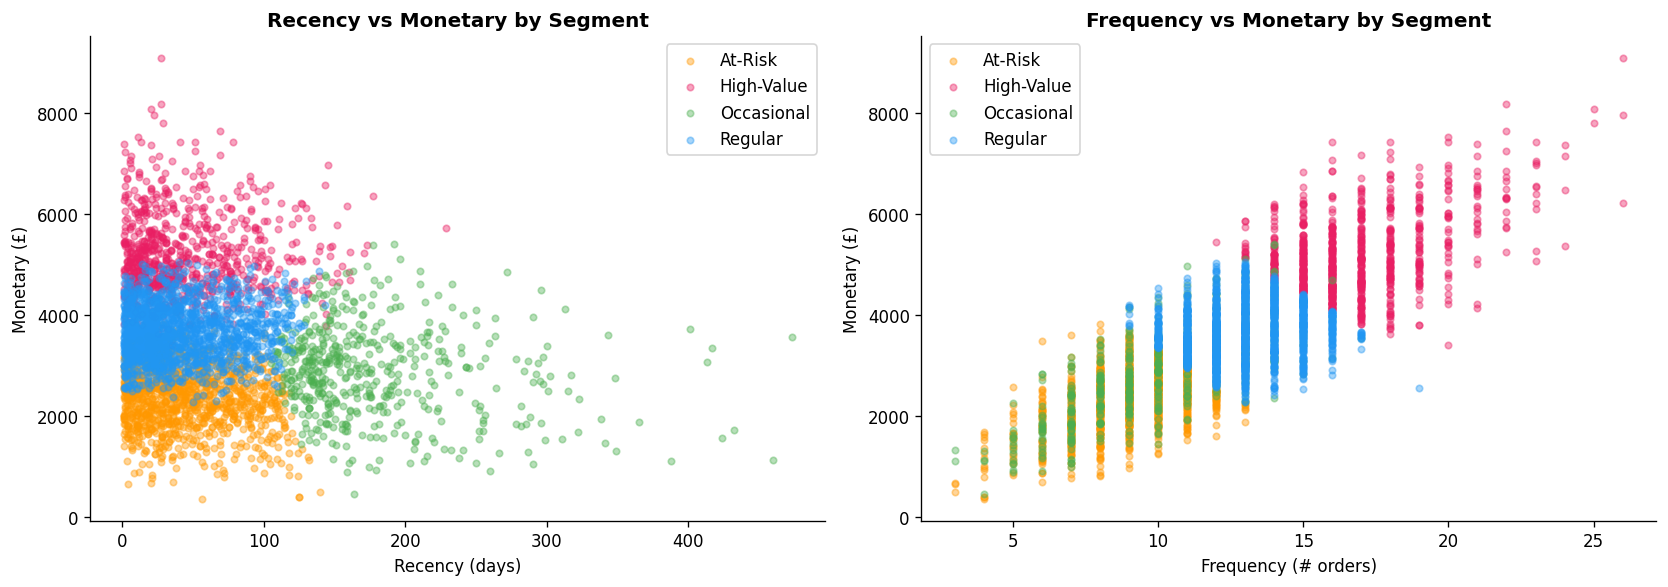

In [19]:
# ── 4.8 Cluster visualisation ────────────────────────────────────────────────
palette = {'High-Value': '#E91E63', 'Regular': '#2196F3', 'Occasional': '#4CAF50', 'At-Risk': '#FF9800'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Recency vs Monetary
for seg, grp in rfm.groupby('Segment'):
    axes[0].scatter(grp['Recency'], grp['Monetary'], label=seg, alpha=0.4, s=15, color=palette[seg])
axes[0].set_title('Recency vs Monetary by Segment', fontweight='bold')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].legend()

# Scatter: Frequency vs Monetary
for seg, grp in rfm.groupby('Segment'):
    axes[1].scatter(grp['Frequency'], grp['Monetary'], label=seg, alpha=0.4, s=15, color=palette[seg])
axes[1].set_title('Frequency vs Monetary by Segment', fontweight='bold')
axes[1].set_xlabel('Frequency (# orders)')
axes[1].set_ylabel('Monetary (£)')
axes[1].legend()

plt.tight_layout()
plt.savefig('cluster_scatter.png', bbox_inches='tight')
plt.show()

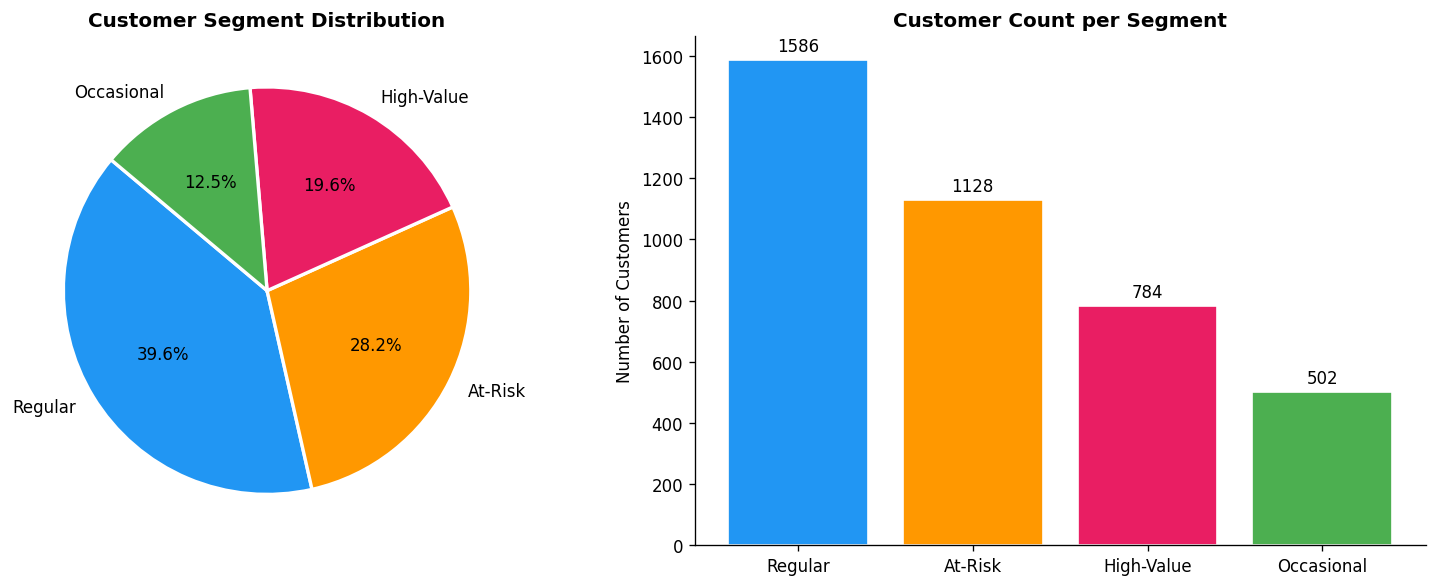

In [20]:
# ── 4.9 Segment distribution pie & bar ───────────────────────────────────────
seg_counts = rfm['Segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(
    seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
    colors=[palette[s] for s in seg_counts.index],
    startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Customer Segment Distribution', fontweight='bold')

bars = axes[1].bar(seg_counts.index, seg_counts.values,
                   color=[palette[s] for s in seg_counts.index], edgecolor='white')
axes[1].bar_label(bars, padding=3)
axes[1].set_title('Customer Count per Segment', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('segment_distribution.png', bbox_inches='tight')
plt.show()

## Step 5: Product Recommendation System (Collaborative Filtering)

In [21]:
# ── 5.1 Build CustomerID × Product purchase matrix ───────────────────────────
# Use top N products for computational efficiency
top_n_products = 150
top_prods = df.groupby('Description')['Quantity'].sum().nlargest(top_n_products).index

df_top = df[df['Description'].isin(top_prods)]

purchase_matrix = df_top.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

print(f'Purchase matrix shape: {purchase_matrix.shape}')
print('(rows = customers, columns = products)')

Purchase matrix shape: (4000, 150)
(rows = customers, columns = products)


In [22]:
# ── 5.2 Compute product-product cosine similarity ────────────────────────────
# Transpose so rows = products, then compute cosine similarity
product_matrix = purchase_matrix.T  # shape: (products, customers)
cos_sim = cosine_similarity(product_matrix)
similarity_df = pd.DataFrame(cos_sim, index=product_matrix.index, columns=product_matrix.index)

print(f'Similarity matrix shape: {similarity_df.shape}')
print('\nSample similarities for first product:')
similarity_df.iloc[0].sort_values(ascending=False).head(6)

Similarity matrix shape: (150, 150)

Sample similarities for first product:


Description
ASSORTED COLOUR BIRD ORNAMENT    1.000000
PRODUCT 156                      0.158767
PRODUCT 150                      0.151005
PRODUCT 171                      0.150600
PRODUCT 018                      0.148932
PRODUCT 231                      0.148629
Name: ASSORTED COLOUR BIRD ORNAMENT, dtype: float64

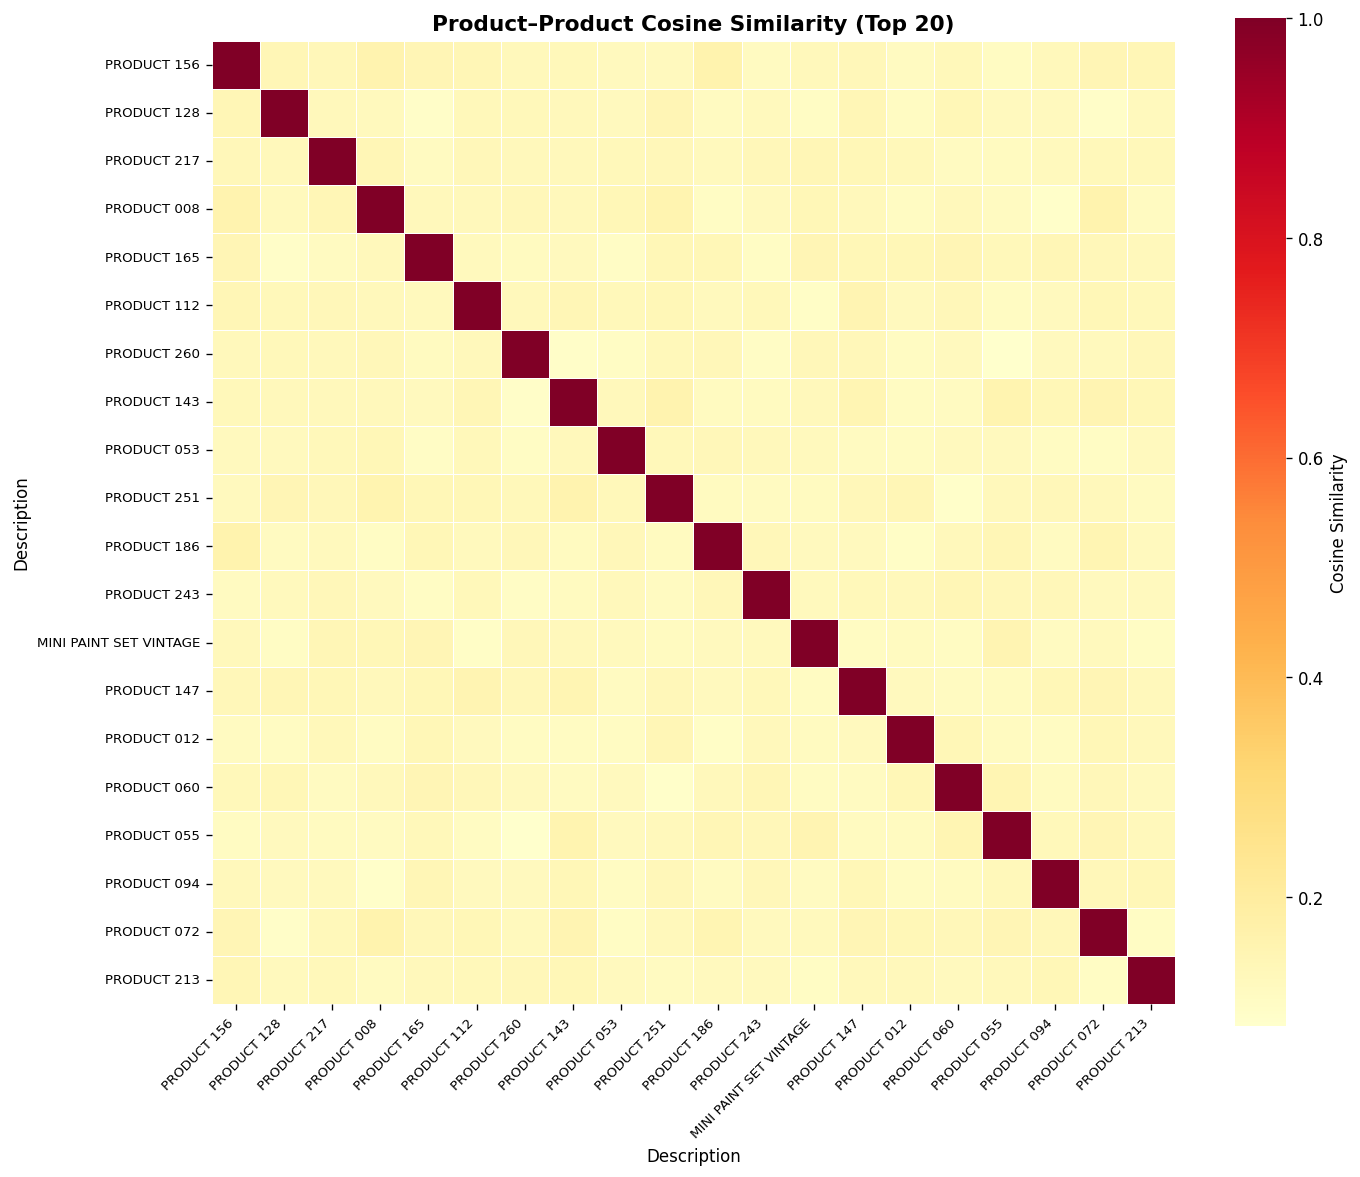

In [23]:
# ── 5.3 Product similarity heatmap (top 20 products) ─────────────────────────
top20 = top_prods[:20]
sim_top20 = similarity_df.loc[top20, top20]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    sim_top20, ax=ax, cmap='YlOrRd', linewidths=0.3, square=True,
    xticklabels=[p[:25] + '…' if len(p) > 25 else p for p in sim_top20.columns],
    yticklabels=[p[:25] + '…' if len(p) > 25 else p for p in sim_top20.index],
    annot=False, cbar_kws={'label': 'Cosine Similarity'}
)
ax.set_title('Product–Product Cosine Similarity (Top 20)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', bbox_inches='tight')
plt.show()

In [24]:
# ── 5.4 Recommendation function ───────────────────────────────────────────────
def get_recommendations(product_name: str, n: int = 5) -> pd.DataFrame:
    """Return top-n similar products for a given product name (case-insensitive)."""
    product_name = product_name.strip().upper()
    
    if product_name not in similarity_df.index:
        # Fuzzy partial match
        matches = [p for p in similarity_df.index if product_name in p]
        if not matches:
            return pd.DataFrame({'Message': [f'Product "{product_name}" not found in the catalogue.']})
        product_name = matches[0]
    
    similar = (
        similarity_df[product_name]
        .drop(product_name)                # exclude itself
        .sort_values(ascending=False)
        .head(n)
        .reset_index()
    )
    similar.columns = ['Recommended Product', 'Similarity Score']
    similar['Similarity Score'] = similar['Similarity Score'].round(4)
    return similar

# Demo
sample_product = similarity_df.index[2]
print(f'Recommendations for: "{sample_product}"\n')
get_recommendations(sample_product)

Recommendations for: "ENAMEL FLOWER JUG"



,Recommended Product,Similarity Score
0,PRODUCT 008,0.1538
1,PRODUCT 013,0.1518
2,MINI PAINT SET VINTAGE,0.1511
3,PRODUCT 060,0.1501
4,WHITE HANGING HEART T-LIGHT HOLDER,0.1500


## Step 6: Save Models for Streamlit App

In [25]:
# ── Save all artefacts ────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

# KMeans model + scaler
with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Segment label mapping
with open('models/label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

# Similarity matrix
similarity_df.to_pickle('models/similarity_df.pkl')

# RFM with segments
rfm.to_csv('models/rfm_segments.csv', index=False)

print('All models saved ✅')
print(os.listdir('models'))

All models saved ✅
['label_map.pkl', 'similarity_df.pkl', 'rfm_segments.csv', 'kmeans_model.pkl', 'scaler.pkl']


## Step 7: Model Evaluation Summary

In [26]:
# ── Evaluation metrics ────────────────────────────────────────────────────────
eval_data = {
    'Metric': [
        'Number of Clusters',
        'Silhouette Score',
        'Inertia',
        'Total Customers Segmented',
        'Products in Recommendation System',
        'Similarity Metric',
    ],
    'Value': [
        OPTIMAL_K,
        round(sil, 4),
        round(kmeans.inertia_, 2),
        len(rfm),
        len(similarity_df),
        'Cosine Similarity',
    ]
}
pd.DataFrame(eval_data)

,Metric,Value
0,Number of Clusters,4
1,Silhouette Score,0.3052
2,Inertia,4086.61
3,Total Customers Segmented,4000
4,Products in Recommendation System,150
5,Similarity Metric,Cosine Similarity


In [27]:
print('🎉 Project pipeline complete!')
print('Next: run  streamlit run app.py  to launch the web app.')

🎉 Project pipeline complete!
Next: run  streamlit run app.py  to launch the web app.
